<a href="https://colab.research.google.com/github/Ramprashanth17/Gen_AI/blob/main/rag-learning-platform/notebooks/4_RAG_Pipeline_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 Tutorial 04: Building the Complete RAG Pipeline

**Learning Objectives:**
- Connect all RAG components into a working system
- Master prompt engineering for RAG applications
- Compare RAG vs non-RAG answers to see the difference
- Implement error handling and edge cases
- Evaluate RAG system performance
- Build a production-ready RAG query function

**Prerequisites:**
- ✅ Completed `01_embeddings_fundamentals.ipynb`
- ✅ Completed `02_chunking_and_tokenization.ipynb`
- ✅ Completed `03_vector_storage_chromadb.ipynb`
- ✅ Understand embeddings, chunking, vector storage, and cosine similarity

**Time Required:** 50-60 minutes

---

## 📖 Table of Contents
1. [The RAG Promise: Why Bother?](#problem)
2. [Building the RAG Query Function](#building)
3. [Prompt Engineering for RAG](#prompting)
4. [The WOW Moment: RAG vs Baseline](#comparison)
5. [Advanced: Multi-Query RAG](#advanced)
6. [Error Handling & Edge Cases](#errors)
7. [Evaluation Metrics](#evaluation)
8. [Common Doubts & Pitfalls](#doubts)
9. [Practice Exercises](#exercises)

---

**Author:** Ramprashanth | INFO 7390 Final Project | December 2025

**🔗 Previous Tutorials:**
- [1_Embeddings_Fundamentals.ipynb](https://github.com/Ramprashanth17/Gen_AI/blob/main/rag-learning-platform/notebooks/1_Embeddings_Fundamentals.ipynb)
- [2_Chunking_and_tokenization.ipynb](https://github.com/Ramprashanth17/Gen_AI/blob/main/rag-learning-platform/notebooks/2_Chunking_and_Tokenization.ipynb)
- [3_Vector_storage_chromadb.ipynb](https://github.com/Ramprashanth17/Gen_AI/blob/main/rag-learning-platform/notebooks/3_Vector_Storage_Chromadb.ipynb)

**⏭️ Next:**
- `DEMO_full_rag_system.ipynb` - Everything in one streamlined demo!

### Setup and Getting Started!

In [ ]:
# Install packages
!pip install -q chromadb sentence-transformers google-generativeai tiktoken matplotlib

In [ ]:
# Imports
import chromadb
from sentence_transformers import SentenceTransformer
import google.generativeai as genai
from google.colab import userdata
import tiktoken
import time
from typing import List, Dict, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configure Gemini
try:
    GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("✅ Gemini API configured")
except Exception as e:
    print(f"⚠️ API key error: {e}")
    print("Please set GEMINI_API_KEY in Colab Secrets")

# Initialize models
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
llm_model = genai.GenerativeModel('gemini-2.5-flash')

print("✅ Setup complete!")
print(f"📊 Embedding model: all-MiniLM-L6-v2 (384 dimensions)")
print(f"🤖 LLM model: Gemini 2.5 Flash")

<a id="problem"></a>
## 🤔 The RAG Promise: Why Bother With All This?

### The LLM Hallucination Problem

**Scenario:** You ask an LLM about your company's specific policies.
```python
# Without RAG - Just asking Gemini directly
query = "What is our company's remote work policy?"

response = llm.generate_content(query)
print(response.text)

# Possible output:
# "Most companies allow 2-3 days remote work per week..."
# ⚠️ GENERIC! Not YOUR company's actual policy!
# ⚠️ Could be completely wrong!
# ⚠️ No sources cited!
```

**Problems:**
- ❌ **Hallucination:** LLM makes up plausible-sounding but wrong answers
- ❌ **No specificity:** Generic knowledge, not YOUR data
- ❌ **No citations:** Can't verify the information
- ❌ **Outdated:** Training data might be old

---

### The RAG Solution

**Same question, but with RAG:**
```python
# With RAG - Provide relevant context first
query = "What is our company's remote work policy?"

# 1. Find relevant chunks from YOUR documents
relevant_chunks = vector_db.search(query, top_k=3)
# Returns: Actual policy text from employee_handbook.pdf

# 2. Give LLM the context
prompt = f"""
Context from company handbook:
{relevant_chunks}

Question: {query}

Answer based ONLY on the provided context:
"""

# 3. Generate grounded answer
response = llm.generate_content(prompt)

# Output:
# "According to the employee handbook (page 23), employees may
#  work remotely up to 3 days per week with manager approval..."
# ✅ SPECIFIC to your company!
# ✅ CITED source (page 23)!
# ✅ ACCURATE (from actual document)!
```

---

### The RAG Architecture (What You Built!)
```
USER QUESTION: "What is the remote work policy?"
        ↓
    ┌───────────────────────────────────────┐
    │  1. EMBED QUERY (Tutorial 01)         │
    │     "What is..." → [0.23, 0.89, ...]  │
    └───────────────────────────────────────┘
        ↓
    ┌───────────────────────────────────────┐
    │  2. VECTOR SEARCH (Tutorial 03)       │
    │     Find similar chunks in ChromaDB   │
    │     Top 3: [Chunk 15, Chunk 23, ...]  │
    └───────────────────────────────────────┘
        ↓
    ┌───────────────────────────────────────┐
    │  3. BUILD CONTEXT (Tutorial 02)       │
    │     Combine chunks with metadata      │
    │     Context = Chunk 15 + 23 + 31      │
    └───────────────────────────────────────┘
        ↓
    ┌───────────────────────────────────────┐
    │  4. PROMPT ENGINEERING (Tutorial 04!) │
    │     Create effective prompt for LLM   │
    └───────────────────────────────────────┘
        ↓
    ┌───────────────────────────────────────┐
    │  5. GENERATE ANSWER (Tutorial 04!)    │
    │     LLM creates grounded response     │
    │     WITH source citations!            │
    └───────────────────────────────────────┘
        ↓
    ACCURATE, CITED ANSWER ✅
```

**This is what we're building today!** 🎯

In [ ]:
# ═══════════════════════════════════════════════════════
# 📚 STEP 1: Create Our Knowledge Base
# ═══════════════════════════════════════════════════════

print("📚 BUILDING KNOWLEDGE BASE")
print("="*70)

# Sample documents (simulating a dog care guide)
knowledge_base = [
    {
        "text": "Dogs need at least 30-60 minutes of daily exercise depending on breed and age. High-energy breeds like Border Collies and Australian Shepherds may need 2+ hours. Regular exercise prevents obesity, reduces anxiety, and promotes better behavior. Activities can include walks, runs, fetch, swimming, or agility training.",
        "metadata": {
            "source": "dog_care_guide.pdf",
            "page": 12,
            "section": "Exercise Requirements",
            "topic": "exercise"
        }
    },
    {
        "text": "A balanced dog diet should contain high-quality protein (chicken, beef, fish), healthy fats (omega-3, omega-6), carbohydrates (rice, sweet potato), and essential vitamins and minerals. Feed adult dogs twice daily. Portion sizes depend on weight, age, and activity level. Avoid chocolate, grapes, onions, and xylitol - these are toxic to dogs.",
        "metadata": {
            "source": "dog_care_guide.pdf",
            "page": 18,
            "section": "Nutrition Guidelines",
            "topic": "nutrition"
        }
    },
    {
        "text": "Puppy training should begin at 8-10 weeks old. Start with basic commands: sit, stay, come, down, and leave it. Use positive reinforcement - reward desired behaviors with treats, praise, or play. Training sessions should be 10-15 minutes, 2-3 times daily. Consistency is crucial. Never use physical punishment as it damages trust and can create fear-based behaviors.",
        "metadata": {
            "source": "training_manual.pdf",
            "page": 5,
            "section": "Basic Training",
            "topic": "training"
        }
    },
    {
        "text": "Schedule annual vet checkups for adult dogs. Puppies need visits every 3-4 weeks until 16 weeks old for vaccinations. Senior dogs (7+ years) should see the vet twice annually. Watch for warning signs: lethargy, loss of appetite, excessive thirst, vomiting, diarrhea, or behavioral changes. Early detection saves lives and reduces treatment costs.",
        "metadata": {
            "source": "health_guide.pdf",
            "page": 8,
            "section": "Veterinary Care",
            "topic": "health"
        }
    },
    {
        "text": "Common dog health issues include dental disease (affects 80% of dogs by age 3), obesity (affects 56% of dogs), arthritis in senior dogs, ear infections, and skin allergies. Regular dental cleaning, weight management, and preventive care reduce these risks. Pet insurance can help manage unexpected veterinary costs.",
        "metadata": {
            "source": "health_guide.pdf",
            "page": 15,
            "section": "Common Health Issues",
            "topic": "health"
        }
    },
    {
        "text": "Grooming needs vary by breed. Long-haired breeds need daily brushing to prevent matting. Short-haired breeds can be brushed weekly. Bathe dogs every 4-8 weeks or as needed. Trim nails monthly. Clean ears weekly to prevent infections. Regular grooming strengthens your bond and lets you check for skin issues or parasites.",
        "metadata": {
            "source": "grooming_guide.pdf",
            "page": 3,
            "section": "Grooming Basics",
            "topic": "grooming"
        }
    }
]

print(f"✅ Created knowledge base with {len(knowledge_base)} documents")
print(f"📊 Topics covered: exercise, nutrition, training, health, grooming")

# Display preview
print("\n📋 KNOWLEDGE BASE PREVIEW:")
print("-"*70)
for i, doc in enumerate(knowledge_base[:3], 1):
    print(f"\nDocument {i}:")
    print(f"  Topic: {doc['metadata']['topic']}")
    print(f"  Source: {doc['metadata']['source']}, Page {doc['metadata']['page']}")
    print(f"  Text: {doc['text'][:80]}...")



In [ ]:
# ═══════════════════════════════════════════════════════
# 📚 STEP 2: Store in ChromaDB
# ═══════════════════════════════════════════════════════

print("\n" + "="*70)
print("💾 STORING IN CHROMADB")
print("="*70)

# Create ChromaDB client and collection
client = chromadb.Client()
collection = client.create_collection(
    name="dog_care_kb",
    metadata={"hnsw:space": "cosine"}  # Use cosine similarity!
)

# Generate embeddings
texts = [doc['text'] for doc in knowledge_base]
embeddings = embedding_model.encode(texts)

print(f"✅ Generated {len(embeddings)} embeddings")
print(f"   Shape: {embeddings.shape}")

# Store in ChromaDB
collection.add(
    ids=[f"doc_{i}" for i in range(len(knowledge_base))],
    documents=texts,
    embeddings=embeddings.tolist(),
    metadatas=[doc['metadata'] for doc in knowledge_base]
)

print(f"✅ Stored {collection.count()} documents in ChromaDB")
print("\n🎯 Knowledge base ready for RAG queries! 🚀")

<a id="building"></a>
## 🔨 Building the RAG Query Function

Now let's build the **core RAG function** that brings everything together!

### The RAG Pipeline (Step by Step)
```
Query → Embed → Search → Retrieve → Build Prompt → Generate → Return
```

Let's implement each step:

In [ ]:
# ═══════════════════════════════════════════════════════
# 🔨 BUILDING THE RAG QUERY FUNCTION (CORRECTED)
# ═══════════════════════════════════════════════════════

def rag_query(question: str, collection, llm_model, top_k: int = 3, verbose: bool = True) -> Dict:
    """
    Complete RAG pipeline: Retrieve relevant context and generate answer.

    Args:
        question: User's question
        collection: ChromaDB collection with documents
        llm_model: Gemini model for generation
        top_k: Number of chunks to retrieve
        verbose: Print step-by-step process

    Returns:
        Dict with answer, sources, context, and metrics
    """

    if verbose:
        print("🔄 RAG PIPELINE EXECUTING...")
        print("="*70)

    # ═══════════════════════════════════════════════════════
    # STEP 1: Retrieve Relevant Chunks
    # ═══════════════════════════════════════════════════════

    start_time = time.time()

    if verbose:
        print(f"\n1️⃣ RETRIEVING relevant chunks for: '{question}'")

    # Search vector database
    results = collection.query(
        query_texts=[question],
        n_results=top_k
    )

    # Extract results
    retrieved_docs = results['documents'][0]
    retrieved_metadata = results['metadatas'][0]
    distances = results['distances'][0]
    similarities = [1 - d for d in distances]

    retrieval_time = time.time() - start_time

    if verbose:
        print(f"   ✅ Retrieved {len(retrieved_docs)} chunks in {retrieval_time:.3f}s")
        for i, (doc, meta, sim) in enumerate(zip(retrieved_docs, retrieved_metadata, similarities), 1):
            print(f"   {i}. {meta['section']} (similarity: {sim:.3f})")

    # ═══════════════════════════════════════════════════════
    # STEP 2: Build Context from Retrieved Chunks
    # ═══════════════════════════════════════════════════════

    if verbose:
        print(f"\n2️⃣ BUILDING context from retrieved chunks")

    # Format context with sources
    context_parts = []
    for i, (doc, meta) in enumerate(zip(retrieved_docs, retrieved_metadata), 1):
        context_parts.append(
            f"[Source {i}: {meta['source']}, Page {meta['page']}, Section: {meta['section']}]\n{doc}"
        )

    context = "\n\n".join(context_parts)

    # Calculate context tokens (MOVED OUTSIDE verbose block - BUG FIX!)
    tokenizer = tiktoken.get_encoding("cl100k_base")
    context_tokens = len(tokenizer.encode(context))

    if verbose:
        print(f"   ✅ Context built: {len(context)} characters")
        print(f"   📊 Context tokens: {context_tokens}")

    # ═══════════════════════════════════════════════════════
    # STEP 3: Create RAG Prompt
    # ═══════════════════════════════════════════════════════

    if verbose:
        print(f"\n3️⃣ CREATING RAG prompt")

    prompt = f"""You are a helpful assistant answering questions about dog care.

Context Information (from trusted sources):
{context}

User Question: {question}

Instructions:
- Answer the question using ONLY the information provided in the context above
- If the context doesn't contain enough information, say so clearly
- Cite your sources using the [Source X] references provided
- Be concise but complete (2-4 sentences)
- Provide actionable advice when appropriate

Answer:"""

    if verbose:
        prompt_tokens = len(tokenizer.encode(prompt))
        print(f"   ✅ Prompt created: {prompt_tokens} tokens total")

    # ═══════════════════════════════════════════════════════
    # STEP 4: Generate Answer with LLM
    # ═══════════════════════════════════════════════════════

    if verbose:
        print(f"\n4️⃣ GENERATING answer with Gemini")

    generation_start = time.time()

    try:
        response = llm_model.generate_content(prompt)
        answer = response.text
        generation_time = time.time() - generation_start

        if verbose:
            print(f"   ✅ Answer generated in {generation_time:.3f}s")
            response_tokens = len(tokenizer.encode(answer))
            print(f"   📊 Response tokens: {response_tokens}")

    except Exception as e:
        answer = f"Error generating response: {str(e)}"
        generation_time = 0
        if verbose:
            print(f"   ❌ Error: {e}")

    # ═══════════════════════════════════════════════════════
    # STEP 5: Package Results
    # ═══════════════════════════════════════════════════════

    total_time = time.time() - start_time

    result = {
        'question': question,
        'answer': answer,
        'sources': [
            {
                'text': doc,
                'source': meta['source'],
                'page': meta['page'],
                'section': meta['section'],
                'similarity': sim
            }
            for doc, meta, sim in zip(retrieved_docs, retrieved_metadata, similarities)
        ],
        'context': context,
        'metrics': {
            'retrieval_time': retrieval_time,
            'generation_time': generation_time,
            'total_time': total_time,
            'context_tokens': context_tokens,  # Now always defined!
            'chunks_retrieved': len(retrieved_docs),
            'avg_similarity': np.mean(similarities)
        }
    }

    if verbose:
        print(f"\n" + "="*70)
        print(f"✅ RAG QUERY COMPLETE in {total_time:.3f}s")
        print("="*70)

    return result


In [ ]:
# ═══════════════════════════════════════════════════════
# 🧪 TEST THE RAG FUNCTION
# ═══════════════════════════════════════════════════════

print("\n🧪 TESTING RAG QUERY FUNCTION")
print("="*70)

test_question = "How much exercise does a dog need?"

result = rag_query(
    question=test_question,
    collection=collection,
    llm_model=llm_model,
    top_k=3,
    verbose=True
)

print("\n" + "="*70)
print("📝 FINAL ANSWER:")
print("="*70)
print(result['answer'])

print("\n" + "="*70)
print("📚 SOURCES USED:")
print("="*70)
for i, source in enumerate(result['sources'], 1):
    print(f"\n{i}. {source['source']}, Page {source['page']}")
    print(f"   Section: {source['section']}")
    print(f"   Similarity: {source['similarity']:.3f}")
    print(f"   Text: {source['text'][:100]}...")

<a id="prompting"></a>
## 🎨 Prompt Engineering for RAG

**The prompt is CRITICAL!** A bad prompt wastes good retrieval.

### Anatomy of a Good RAG Prompt
```python
# ❌ BAD RAG PROMPT (Too simple)
prompt = f"{context}\n\nQuestion: {question}"
# Problems:
# - No instructions to stay grounded
# - No citation guidance
# - LLM might ignore context and hallucinate anyway

# ✅ GOOD RAG PROMPT (Structured)
prompt = f"""
You are a helpful assistant.

Context (from verified sources):
{context}

Question: {question}

Instructions:
- Answer using ONLY the context provided
- Cite sources using [Source X] format
- If context insufficient, say "I don't have enough information"
- Be concise but complete

Answer:
"""
```

---

### Key Prompt Engineering Principles

**1. Set Clear Role**
```python
"You are an expert dog care advisor..." ✅
vs
"You are an AI..." ❌ (too generic)
```

**2. Emphasize Grounding**
```python
"Answer using ONLY the context provided" ✅
"If the context doesn't have the info, say so" ✅
```

**3. Request Citations**
```python
"Cite sources using [Source X] format" ✅
"Include page numbers when relevant" ✅
```

**4. Specify Format**
```python
"Provide a concise answer in 2-3 sentences" ✅
"List key points with bullet points" ✅
```

**5. Handle Uncertainty**
```python
"If unsure, say 'Based on the available information...'" ✅
"Never make up information" ✅
```

In [ ]:
# ═══════════════════════════════════════════════════════
# 🔬 EXPERIMENT: Different Prompt Styles
# ═══════════════════════════════════════════════════════

print("🔬 PROMPT ENGINEERING EXPERIMENTS")
print("="*70)

question = "What should I feed my dog?"

# Get context (same for all prompts)
results = collection.query(query_texts=[question], n_results=2)
context = "\n\n".join(results['documents'][0])

# ───────────────────────────────────────────────────────
# Prompt Style 1: Minimal (Baseline)
# ───────────────────────────────────────────────────────

prompt_minimal = f"{context}\n\nQuestion: {question}\n\nAnswer:"

print("\n📝 STYLE 1: Minimal Prompt")
print("-"*70)
print("Prompt:", prompt_minimal[:100] + "...")

response1 = llm_model.generate_content(prompt_minimal)
print(f"\nResponse: {response1.text}")





In [ ]:
# ───────────────────────────────────────────────────────
# Prompt Style 2: Structured (Recommended)
# ───────────────────────────────────────────────────────

prompt_structured = f"""You are a helpful dog care expert.

Context from verified sources:
{context}

Question: {question}

Instructions:
- Answer using ONLY the context above
- Cite specific sources when possible
- Be concise (2-3 sentences)

Answer:"""

print("\n" + "="*70)
print("📝 STYLE 2: Structured Prompt")
print("-"*70)

response2 = llm_model.generate_content(prompt_structured)
print(f"\nResponse: {response2.text}")

In [ ]:
# ───────────────────────────────────────────────────────
# Prompt Style 3: Detailed Instructions (Best)
# ───────────────────────────────────────────────────────

prompt_detailed = f"""You are an expert dog care advisor helping pet owners.

CONTEXT (from trusted veterinary sources):
{context}

USER QUESTION: {question}

INSTRUCTIONS:
1. Answer the question using ONLY the information in the context above
2. If the context doesn't contain relevant information, clearly state: "I don't have specific information about that in the provided sources"
3. Cite your sources by mentioning the relevant information
4. Provide practical, actionable advice
5. Keep your answer concise (3-4 sentences maximum)
6. Do not add information not present in the context

YOUR ANSWER:"""

print("\n" + "="*70)
print("📝 STYLE 3: Detailed Instructions")
print("-"*70)

response3 = llm_model.generate_content(prompt_detailed)
print(f"\nResponse: {response3.text}")

print("\n" + "="*70)
print("🎯 COMPARISON:")
print("Style 1: Basic, may hallucinate")
print("Style 2: Better, includes citations")
print("Style 3: Best, grounded and actionable ✅")
print("\nRecommendation: Use Style 3 for production!")
print("="*70)

<a id="comparison"></a>
## ✨ The WOW Moment: RAG vs Non-RAG Comparison

**This is where you see the MAGIC of RAG!**

Let's ask questions that the LLM wouldn't know without RAG.

In [ ]:
# ═══════════════════════════════════════════════════════
# ✨ RAG vs Baseline Comparison (RATE-LIMIT SAFE)
# ═══════════════════════════════════════════════════════

def compare_rag_vs_baseline(question: str, collection, llm_model, top_k: int = 3,
                            delay_between_calls: float = 5.0):
    """
    Compare RAG answer vs baseline LLM answer side-by-side.

    RATE LIMIT SAFE: Adds delays between API calls
    """
    print("="*70)
    print(f"🔍 QUESTION: {question}")
    print("="*70)

    # ───────────────────────────────────────────────────────
    # BASELINE: Ask LLM directly (no context)
    # ───────────────────────────────────────────────────────

    print("\n❌ WITHOUT RAG (Baseline LLM):")
    print("-"*70)

    baseline_start = time.time()

    try:
        baseline_response = llm_model.generate_content(question)
        baseline_answer = baseline_response.text
        baseline_time = time.time() - baseline_start

        print(baseline_answer)
        print(f"\n⏱️  Time: {baseline_time:.3f}s")
        print("⚠️  Issues: Generic, no sources, might be inaccurate")

    except Exception as e:
        if "429" in str(e) or "quota" in str(e).lower():
            print("⚠️ RATE LIMIT HIT - Skipping baseline for this query")
            print("💡 In production, implement exponential backoff retry")
            baseline_answer = "[Rate limited - skipped]"
            baseline_time = 0
        else:
            print(f"❌ Error: {e}")
            baseline_answer = f"Error: {e}"
            baseline_time = 0

    # ⏸️ RATE LIMIT PROTECTION: Wait before next call
    print(f"\n⏸️  Waiting {delay_between_calls}s to avoid rate limits...")
    time.sleep(delay_between_calls)

    # ───────────────────────────────────────────────────────
    # RAG: Retrieve context first, then answer
    # ───────────────────────────────────────────────────────

    print("\n" + "="*70)
    print("✅ WITH RAG (Context-Enhanced):")
    print("-"*70)

    try:
        rag_result = rag_query(
            question=question,
            collection=collection,
            llm_model=llm_model,
            top_k=top_k,
            verbose=False
        )

        print(rag_result['answer'])
        print(f"\n📚 Sources:")
        for i, source in enumerate(rag_result['sources'], 1):
            print(f"   {i}. {source['source']}, Page {source['page']} (similarity: {source['similarity']:.3f})")
        print(f"\n⏱️  Time: {rag_result['metrics']['total_time']:.3f}s")
        print(f"📊 Retrieved: {rag_result['metrics']['chunks_retrieved']} chunks, {rag_result['metrics']['context_tokens']} tokens")

    except Exception as e:
        if "429" in str(e) or "quota" in str(e).lower():
            print("⚠️ RATE LIMIT HIT")
            print(f"💡 Please wait 60 seconds and try again")
            rag_result = None
        else:
            print(f"❌ Error: {e}")
            rag_result = None

    # ───────────────────────────────────────────────────────
    # Side-by-side comparison (if both succeeded)
    # ───────────────────────────────────────────────────────

    if rag_result and baseline_answer != "[Rate limited - skipped]":
        print("\n" + "="*70)
        print("📊 COMPARISON SUMMARY:")
        print("="*70)

        comparison_df = pd.DataFrame({
            'Metric': [
                'Response Quality',
                'Sources Cited',
                'Specific to Query',
                'Verifiable',
                'Processing Time',
                'Cost (estimate)'
            ],
            'Baseline (No RAG)': [
                '⭐⭐⭐ Generic',
                '❌ None',
                '⚠️ General knowledge',
                '❌ No',
                f'{baseline_time:.3f}s',
                '~$0.00001'
            ],
            'RAG-Enhanced': [
                '⭐⭐⭐⭐⭐ Precise',
                f"✅ {len(rag_result['sources'])} sources",
                '✅ Domain-specific',
                '✅ Yes (with pages)',
                f"{rag_result['metrics']['total_time']:.3f}s",
                f"~$0.0003 ({rag_result['metrics']['context_tokens']} tokens)"
            ]
        })

        print(comparison_df.to_string(index=False))

        print("\n🎯 VERDICT:")
        print("RAG costs 30x more but provides:")
        print("  ✅ Accurate, specific answers")
        print("  ✅ Verifiable sources")
        print("  ✅ Domain expertise")
        print("  ✅ Up-to-date information")
        print("\nFor critical applications: RAG is worth it! 💯")

    # ⏸️ Wait before returning
    time.sleep(delay_between_calls)

    return {
        'baseline': baseline_answer if 'baseline_answer' in locals() else None,
        'rag': rag_result['answer'] if rag_result else None,
        'baseline_time': baseline_time if 'baseline_time' in locals() else 0,
        'rag_time': rag_result['metrics']['total_time'] if rag_result else 0
    }


# ═══════════════════════════════════════════════════════
# 🧪 TEST: With Proper Rate Limiting
# ═══════════════════════════════════════════════════════

print("\n\n🧪 TESTING WITH RATE LIMIT PROTECTION")
print("="*70)
print("⚠️ Note: Each comparison takes ~10 seconds due to API limits")
print("="*70)

test_questions = [
    "How much exercise does a dog need daily?",
    "What foods are toxic to dogs?",
    # "When should I start training my puppy?"  # Comment out to save API calls
]

for i, question in enumerate(test_questions, 1):
    print(f"\n{'🔹'*35}")
    print(f"Test {i}/{len(test_questions)}")
    print(f"{'🔹'*35}")

    compare_rag_vs_baseline(
        question,
        collection,
        llm_model,
        top_k=2,
        delay_between_calls=12  # 12 second delay (safe for free tier)
    )

print("\n" + "="*70)
print("✅ COMPARISON COMPLETE!")
print("="*70)

## ⚠️ Important: API Rate Limits

### What Just Happened?

If you saw a `429 TooManyRequests` error, you hit Gemini's rate limit!

**Gemini Free Tier Limits:**
- 5 requests per minute
- 1,500 requests per day

**Why This Matters for RAG:**
```python
# Each RAG query = 1 API call
# Each baseline query = 1 API call
# Comparison = 2 API calls per question

# Testing 3 questions:
3 questions × 2 calls = 6 API calls
But limit = 5 calls/minute
→ Error on 6th call! ⚠️
```

---

### Solutions:

**1. Add Delays (Simple)**
```python
time.sleep(12)  # Wait 12 seconds between queries
# Stays under 5 per minute
```

**2. Batch Processing (Better)**
```python
# Test in batches
questions_batch_1 = questions[:2]  # First 2
time.sleep(60)  # Wait 1 minute
questions_batch_2 = questions[2:4]  # Next 2
```

**3. Exponential Backoff (Production)**
```python
# Automatically retry with increasing delays
# 5s → 10s → 20s → 40s
```

**4. Upgrade API Plan (For production)**
- Gemini paid tier: 1000+ RPM
- No rate limits for serious applications



### Query which could result in the above error

```
# ═══════════════════════════════════════════════════════
# ✨ THE WOW MOMENT: RAG vs Baseline Comparison
# ═══════════════════════════════════════════════════════

def compare_rag_vs_baseline(question: str, collection, llm_model, top_k: int = 3):
    """
    Compare RAG answer vs baseline LLM answer side-by-side.
    """
    print("="*70)
    print(f"🔍 QUESTION: {question}")
    print("="*70)
    
    # ───────────────────────────────────────────────────────
    # BASELINE: Ask LLM directly (no context)
    # ───────────────────────────────────────────────────────
    
    print("\n❌ WITHOUT RAG (Baseline LLM):")
    print("-"*70)
    
    baseline_start = time.time()
    baseline_response = llm_model.generate_content(question)
    baseline_time = time.time() - baseline_start
    
    print(baseline_response.text)
    print(f"\n⏱️  Time: {baseline_time:.3f}s")
    print("⚠️  Issues: Generic, no sources, might be inaccurate")
    
    # ───────────────────────────────────────────────────────
    # RAG: Retrieve context first, then answer
    # ───────────────────────────────────────────────────────
    
    print("\n" + "="*70)
    print("✅ WITH RAG (Context-Enhanced):")
    print("-"*70)
    
    rag_result = rag_query(
        question=question,
        collection=collection,
        llm_model=llm_model,
        top_k=top_k,
        verbose=False  # Quiet mode
    )
    
    print(rag_result['answer'])
    print(f"\n📚 Sources:")
    for i, source in enumerate(rag_result['sources'], 1):
        print(f"   {i}. {source['source']}, Page {source['page']} (similarity: {source['similarity']:.3f})")
    print(f"\n⏱️  Time: {rag_result['metrics']['total_time']:.3f}s")
    print(f"📊 Retrieved: {rag_result['metrics']['chunks_retrieved']} chunks, {rag_result['metrics']['context_tokens']} tokens")
    
    # ───────────────────────────────────────────────────────
    # Side-by-side comparison
    # ───────────────────────────────────────────────────────
    
    print("\n" + "="*70)
    print("📊 COMPARISON SUMMARY:")
    print("="*70)
    
    comparison_df = pd.DataFrame({
        'Metric': [
            'Response Quality',
            'Sources Cited',
            'Specific to Query',
            'Verifiable',
            'Processing Time',
            'Cost (estimate)'
        ],
        'Baseline (No RAG)': [
            '⭐⭐⭐ Generic',
            '❌ None',
            '⚠️ General knowledge',
            '❌ No',
            f'{baseline_time:.3f}s',
            '~$0.00001'
        ],
        'RAG-Enhanced': [
            '⭐⭐⭐⭐⭐ Precise',
            f"✅ {len(rag_result['sources'])} sources",
            '✅ Domain-specific',
            '✅ Yes (with pages)',
            f"{rag_result['metrics']['total_time']:.3f}s",
            f"~$0.0003 ({rag_result['metrics']['context_tokens']} tokens)"
        ]
    })
    
    print(comparison_df.to_string(index=False))
    
    print("\n🎯 VERDICT:")
    print("RAG costs 30x more but provides:")
    print("  ✅ Accurate, specific answers")
    print("  ✅ Verifiable sources")
    print("  ✅ Domain expertise")
    print("  ✅ Up-to-date information")
    print("\nFor critical applications: RAG is worth it! 💯")
    
    return {
        'baseline': baseline_response.text,
        'rag': rag_result['answer'],
        'baseline_time': baseline_time,
        'rag_time': rag_result['metrics']['total_time']
    }


# ═══════════════════════════════════════════════════════
# 🧪 TEST: Multiple Questions
# ═══════════════════════════════════════════════════════

print("\n\n🧪 TESTING WITH DIFFERENT QUESTIONS")
print("="*70)

test_questions = [
    "How much exercise does a dog need daily?",
    "What foods are toxic to dogs?",
    "When should I start training my puppy?"
]

for question in test_questions:
    print("\n" + "🔹"*35)
    compare_rag_vs_baseline(question, collection, llm_model, top_k=2)
    print("🔹"*35)
    time.sleep(2)  # Rate limiting for API

```

In [ ]:
# ═══════════════════════════════════════════════════════
# 📊 VISUALIZING RAG PERFORMANCE
# ═══════════════════════════════════════════════════════

print("📊 RAG PERFORMANCE VISUALIZATION")
print("="*70)

# Test multiple queries and collect metrics
test_queries = [
    "How much exercise do dogs need?",
    "What should I feed my dog?",
    "How do I train my puppy?",
    "When should I visit the vet?",
    "How often should I groom my dog?"
]

metrics_data = []

for query in test_queries:
    result = rag_query(query, collection, llm_model, top_k=3, verbose=False)

    metrics_data.append({
        'Query': query[:30] + "...",
        'Retrieval Time': result['metrics']['retrieval_time'],
        'Generation Time': result['metrics']['generation_time'],
        'Total Time': result['metrics']['total_time'],
        'Chunks Retrieved': result['metrics']['chunks_retrieved'],
        'Avg Similarity': result['metrics']['avg_similarity'],
        'Context Tokens': result['metrics']['context_tokens']
    })

    time.sleep(1)  # Rate limiting

# Create DataFrame
df_metrics = pd.DataFrame(metrics_data)

# ═══════════════════════════════════════════════════════
# Visualization
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Time breakdown
ax1 = axes[0, 0]
x = range(len(df_metrics))
width = 0.35

ax1.bar([i - width/2 for i in x], df_metrics['Retrieval Time'], width,
        label='Retrieval', alpha=0.8, color='#3498db')
ax1.bar([i + width/2 for i in x], df_metrics['Generation Time'], width,
        label='Generation', alpha=0.8, color='#e74c3c')

ax1.set_xlabel('Query')
ax1.set_ylabel('Time (seconds)')
ax1.set_title('RAG Pipeline: Time Breakdown', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"Q{i+1}" for i in x])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Similarity scores
ax2 = axes[0, 1]
ax2.bar(x, df_metrics['Avg Similarity'], alpha=0.8, color='#2ecc71')
ax2.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='High similarity')
ax2.axhline(y=0.4, color='orange', linestyle='--', alpha=0.5, label='Medium similarity')
ax2.set_xlabel('Query')
ax2.set_ylabel('Average Similarity Score')
ax2.set_title('Retrieval Quality: Similarity Scores', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"Q{i+1}" for i in x])
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Token usage
ax3 = axes[1, 0]
ax3.bar(x, df_metrics['Context Tokens'], alpha=0.8, color='#f39c12')
ax3.set_xlabel('Query')
ax3.set_ylabel('Tokens')
ax3.set_title('Context Size: Token Usage', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f"Q{i+1}" for i in x])
ax3.grid(axis='y', alpha=0.3)

# Add cost labels
for i, tokens in enumerate(df_metrics['Context Tokens']):
    cost = tokens * 0.001 / 1000  # Rough estimate
    ax3.text(i, tokens + 5, f'${cost:.5f}', ha='center', fontsize=8)

# Plot 4: Summary metrics table
ax4 = axes[1, 1]
ax4.axis('off')

summary_data = [
    ['Avg Retrieval Time', f"{df_metrics['Retrieval Time'].mean():.3f}s"],
    ['Avg Generation Time', f"{df_metrics['Generation Time'].mean():.3f}s"],
    ['Avg Total Time', f"{df_metrics['Total Time'].mean():.3f}s"],
    ['Avg Similarity', f"{df_metrics['Avg Similarity'].mean():.3f}"],
    ['Avg Context Tokens', f"{df_metrics['Context Tokens'].mean():.0f}"],
    ['Avg Cost/Query', f"${(df_metrics['Context Tokens'].mean() * 0.001 / 1000):.5f}"]
]

table = ax4.table(
    cellText=summary_data,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.6, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style table
for i in range(2):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(summary_data) + 1):
    for j in range(2):
        table[(i, j)].set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')

ax4.set_title('Performance Summary', fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🎯 INSIGHTS FROM VISUALIZATION:")
print("1. Retrieval is FAST (<0.1s typically)")
print("2. Generation takes longer (~1-2s)")
print("3. Similarity scores show retrieval quality")
print("4. Cost is proportional to context size")
print("="*70)

<a id="advanced"></a>
## 🚀 Advanced: Multi-Query RAG

**Problem:** Sometimes one query isn't enough to capture user intent.

**Solution:** Generate multiple variations of the query, retrieve for each, then combine results!

In [ ]:
# # ═══════════════════════════════════════════════════════
# # 🚀 ADVANCED: Multi-Query RAG
# # ═══════════════════════════════════════════════════════

# def multi_query_rag(question: str, collection, llm_model, num_variations: int = 3):
#     """
#     Generate multiple query variations for better retrieval coverage.
#     """

#     print(f"🚀 MULTI-QUERY RAG")
#     print("="*70)
#     print(f"Original question: '{question}'")

#     # ───────────────────────────────────────────────────────
#     # STEP 1: Generate query variations using LLM
#     # ───────────────────────────────────────────────────────

#     variation_prompt = f"""Generate {num_variations} different ways to ask this question:

# Original: "{question}"

# Requirements:
# - Keep the same meaning
# - Use different phrasing and keywords
# - Make them diverse

# Return ONLY the {num_variations} questions, one per line, no numbering."""

#     variation_response = llm_model.generate_content(variation_prompt)
#     variations = [q.strip() for q in variation_response.text.strip().split('\n') if q.strip()][:num_variations]

#     print(f"\n📝 Generated {len(variations)} query variations:")
#     for i, var in enumerate(variations, 1):
#         print(f"   {i}. {var}")

#     # ───────────────────────────────────────────────────────
#     # STEP 2: Retrieve for each variation
#     # ───────────────────────────────────────────────────────

#     print(f"\n🔍 Retrieving for each variation...")

#     all_chunks = []
#     all_similarities = []
#     seen_ids = set()

#     for var in variations:
#         results = collection.query(
#             query_texts=[var],
#             n_results=2  # Get top 2 for each variation
#         )

#         for doc, meta, dist in zip(
#             results['documents'][0],
#             results['metadatas'][0],
#             results['distances'][0]
#         ):
#             chunk_id = f"{meta['source']}_{meta['page']}_{meta['section']}"

#             # Deduplicate
#             if chunk_id not in seen_ids:
#                 seen_ids.add(chunk_id)
#                 all_chunks.append({
#                     'text': doc,
#                     'metadata': meta,
#                     'similarity': 1 - dist
#                 })
#                 all_similarities.append(1 - dist)

#     # Sort by similarity
#     all_chunks.sort(key=lambda x: x['similarity'], reverse=True)

#     # Take top K overall
#     top_chunks = all_chunks[:3]

#     print(f"   ✅ Retrieved {len(all_chunks)} unique chunks total")
#     print(f"   📊 Using top {len(top_chunks)} for context")

#     for i, chunk in enumerate(top_chunks, 1):
#         print(f"   {i}. {chunk['metadata']['section']} (sim: {chunk['similarity']:.3f})")

#     # ───────────────────────────────────────────────────────
#     # STEP 3: Generate answer with combined context
#     # ───────────────────────────────────────────────────────

#     context = "\n\n".join([
#         f"[Source: {c['metadata']['source']}, Page {c['metadata']['page']}]\n{c['text']}"
#         for c in top_chunks
#     ])

#     prompt = f"""Context from verified sources:
# {context}

# Question: {question}

# Answer using the context above, cite sources:"""

#     response = llm_model.generate_content(prompt)

#     print(f"\n💬 ANSWER:")
#     print("-"*70)
#     print(response.text)

#     return {
#         'answer': response.text,
#         'variations': variations,
#         'chunks_retrieved': len(all_chunks),
#         'sources': top_chunks
#     }

# ═══════════════════════════════════════════════════════
# 🧪 TEST: Multi-Query RAG
# ═══════════════════════════════════════════════════════

# result = multi_query_rag(
#     "What's the best way to keep my dog healthy?",
#     collection,
#     llm_model,
#     num_variations=3
# )

# print("\n" + "="*70)
# print("🎯 MULTI-QUERY BENEFIT:")
# print("By asking the question in multiple ways, we retrieve")
# print("MORE diverse, relevant chunks than a single query!")
# print("="*70)


""" Had to comment out as it is making too many API requests """

In [28]:
# ═══════════════════════════════════════════════════════
# 🚀 MULTI-QUERY RAG DEMO (Using Example Results)
# ═══════════════════════════════════════════════════════

print("🚀 MULTI-QUERY RAG DEMONSTRATION")
print("="*70)
print("💡 Note: Using example results to avoid rate limits")
print("="*70)

# Show the concept
original_question = "What's the best way to keep my dog healthy?"

print(f"\n📌 Original Question: '{original_question}'")

# Example variations (what LLM would generate)
example_variations = [
    "What are the most effective strategies for promoting my dog's overall well-being?",
    "How can I best ensure my canine companion stays in peak health?",
    "What are the essential steps for maintaining my pet's long-term vitality?"
]

print(f"\n📝 LLM Generated {len(example_variations)} Variations:")
for i, var in enumerate(example_variations, 1):
    print(f"   {i}. {var}")

# Example retrieval results
print(f"\n🔍 Multi-Query Retrieval Results:")
print("-"*70)

example_results = [
    {
        'section': 'Veterinary Care',
        'similarity': 0.503,
        'source': 'health_guide.pdf',
        'page': 8
    },
    {
        'section': 'Nutrition Guidelines',
        'similarity': 0.468,
        'source': 'dog_care_guide.pdf',
        'page': 18
    },
    {
        'section': 'Exercise Requirements',
        'similarity': 0.455,
        'source': 'dog_care_guide.pdf',
        'page': 12
    }
]

for i, res in enumerate(example_results, 1):
    print(f"   {i}. {res['section']} from {res['source']} (similarity: {res['similarity']:.3f})")

# Example final answer
example_answer = """To keep your dog healthy, focus on three key areas:

1. **Regular Veterinary Care**: Schedule annual checkups for adult dogs and more frequent visits for puppies and seniors. Keep vaccinations up to date [Source 1: health_guide.pdf, Page 8].

2. **Proper Nutrition**: Provide a balanced diet with high-quality protein, healthy fats, and appropriate portions based on weight and activity level [Source 2: dog_care_guide.pdf, Page 18].

3. **Daily Exercise**: Ensure your dog gets 30-60 minutes of physical activity daily, adjusted for breed and age [Source 3: dog_care_guide.pdf, Page 12].

By addressing all three areas consistently, you'll maximize your dog's health and longevity."""

print(f"\n💬 Generated Answer:")
print("-"*70)
print(example_answer)

print("\n" + "="*70)
print("🎯 MULTI-QUERY BENEFIT:")
print("By rephrasing the question 3 different ways, we retrieved:")
print("  ✅ Health care information (vet visits)")
print("  ✅ Nutrition guidance (diet)")
print("  ✅ Exercise requirements (activity)")
print("\nA single query might have missed one of these important aspects!")
print("="*70)

print("\n💡 TO RUN LIVE:")
print("Wait 60 seconds, then uncomment and run:")
print("# result = multi_query_rag(question, collection, llm_model)")

🚀 MULTI-QUERY RAG DEMONSTRATION
💡 Note: Using example results to avoid rate limits

📌 Original Question: 'What's the best way to keep my dog healthy?'

📝 LLM Generated 3 Variations:
   1. What are the most effective strategies for promoting my dog's overall well-being?
   2. How can I best ensure my canine companion stays in peak health?
   3. What are the essential steps for maintaining my pet's long-term vitality?

🔍 Multi-Query Retrieval Results:
----------------------------------------------------------------------
   1. Veterinary Care from health_guide.pdf (similarity: 0.503)
   2. Nutrition Guidelines from dog_care_guide.pdf (similarity: 0.468)
   3. Exercise Requirements from dog_care_guide.pdf (similarity: 0.455)

💬 Generated Answer:
----------------------------------------------------------------------
To keep your dog healthy, focus on three key areas:

1. **Regular Veterinary Care**: Schedule annual checkups for adult dogs and more frequent visits for puppies and seniors. K

<a id="errors"></a>
## 🛡️ Error Handling & Edge Cases

Production RAG systems must handle errors gracefully!

In [26]:
# ═══════════════════════════════════════════════════════
# 🛡️ PRODUCTION-READY: Error Handling
# ═══════════════════════════════════════════════════════

def robust_rag_query(question: str, collection, llm_model, top_k: int = 3) -> Dict:
    """
    RAG query with comprehensive error handling.
    """

    result = {
        'question': question,
        'answer': None,
        'sources': [],
        'error': None,
        'success': False
    }

    try:
        # ───────────────────────────────────────────────────
        # Validation: Check inputs
        # ───────────────────────────────────────────────────

        if not question or not question.strip():
            result['error'] = "Empty question provided"
            return result

        if len(question) > 1000:
            result['error'] = "Question too long (max 1000 chars)"
            return result

        # ───────────────────────────────────────────────────
        # Retrieval with error handling
        # ───────────────────────────────────────────────────

        try:
            retrieval_results = collection.query(
                query_texts=[question],
                n_results=top_k
            )

            if not retrieval_results['documents'][0]:
                result['error'] = "No relevant documents found"
                result['answer'] = "I couldn't find relevant information to answer your question."
                return result

        except Exception as e:
            result['error'] = f"Retrieval error: {str(e)}"
            return result

        # ───────────────────────────────────────────────────
        # Build context
        # ───────────────────────────────────────────────────

        retrieved_docs = retrieval_results['documents'][0]
        retrieved_metadata = retrieval_results['metadatas'][0]
        distances = retrieval_results['distances'][0]

        # Check retrieval quality
        similarities = [1 - d for d in distances]
        if max(similarities) < 0.3:
            result['answer'] = "I found some documents, but they don't seem very relevant to your question. Could you rephrase?"
            result['sources'] = [{'similarity': max(similarities)}]
            result['success'] = True
            return result

        # Build context
        context_parts = []
        for doc, meta in zip(retrieved_docs, retrieved_metadata):
            context_parts.append(f"[{meta['source']}, Page {meta['page']}]\n{doc}")

        context = "\n\n".join(context_parts)

        # ───────────────────────────────────────────────────
        # Generation with error handling
        # ───────────────────────────────────────────────────

        prompt = f"""Context: {context}

Question: {question}

Answer based only on the context, cite sources:"""

        try:
            response = llm_model.generate_content(prompt)
            answer = response.text

        except Exception as e:
            result['error'] = f"Generation error: {str(e)}"
            return result

        # ───────────────────────────────────────────────────
        # Package successful result
        # ───────────────────────────────────────────────────

        result['answer'] = answer
        result['sources'] = [
            {
                'text': doc,
                'source': meta['source'],
                'page': meta['page'],
                'similarity': sim
            }
            for doc, meta, sim in zip(retrieved_docs, retrieved_metadata, similarities)
        ]
        result['success'] = True

    except Exception as e:
        result['error'] = f"Unexpected error: {str(e)}"

    return result


# ═══════════════════════════════════════════════════════
# 🧪 TEST: Error Scenarios
# ═══════════════════════════════════════════════════════

print("\n🧪 TESTING ERROR HANDLING")
print("="*70)

test_cases = [
    "",  # Empty question
    "How to fix a car engine?",  # Irrelevant to knowledge base
    "What do dogs need?" * 500,  # Too long
    "How much exercise do dogs need?"  # Valid question
]

for i, test in enumerate(test_cases, 1):
    print(f"\n{'─'*70}")
    print(f"Test {i}: {test[:50]}{'...' if len(test) > 50 else ''}")
    print(f"{'─'*70}")

    result = robust_rag_query(test, collection, llm_model)

    if result['success']:
        print("✅ Success!")
        print(f"Answer: {result['answer'][:100]}...")
    else:
        print(f"❌ Error: {result['error']}")
        if result['answer']:
            print(f"Fallback answer: {result['answer']}")

    time.sleep(1)

print("\n" + "="*70)
print("🎯 PRODUCTION READINESS:")
print("✅ Handles empty queries")
print("✅ Handles irrelevant queries")
print("✅ Handles overly long queries")
print("✅ Provides helpful error messages")
print("="*70)


🧪 TESTING ERROR HANDLING

──────────────────────────────────────────────────────────────────────
Test 1: 
──────────────────────────────────────────────────────────────────────
❌ Error: Empty question provided

──────────────────────────────────────────────────────────────────────
Test 2: How to fix a car engine?
──────────────────────────────────────────────────────────────────────
✅ Success!
Answer: I found some documents, but they don't seem very relevant to your question. Could you rephrase?...

──────────────────────────────────────────────────────────────────────
Test 3: What do dogs need?What do dogs need?What do dogs n...
──────────────────────────────────────────────────────────────────────
❌ Error: Question too long (max 1000 chars)

──────────────────────────────────────────────────────────────────────
Test 4: How much exercise do dogs need?
──────────────────────────────────────────────────────────────────────


❌ Error: Generation error: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 35.140654253s.

🎯 PRODUCTION READINESS:
✅ Handles empty queries
✅ Handles irrelevant queries
✅ Handles overly long queries
✅ Provides helpful error messages


In [29]:
# ═══════════════════════════════════════════════════════
# 🛡️ ERROR HANDLING DEMONSTRATION (Mock Version)
# ═══════════════════════════════════════════════════════

def demonstrate_error_handling():
    """
    Demonstrate error handling without making API calls.
    Uses mock scenarios to teach the concepts.
    """

    print("🛡️ PRODUCTION-READY ERROR HANDLING")
    print("="*70)
    print("💡 Note: Using mock scenarios to demonstrate (no API calls)")
    print("="*70)

    # ───────────────────────────────────────────────────────
    # Scenario 1: Empty question
    # ───────────────────────────────────────────────────────

    print("\n📝 SCENARIO 1: Empty Question")
    print("-"*70)

    question = ""

    if not question or not question.strip():
        print(f"Input: '{question}'")
        print("❌ Error detected: Empty question provided")
        print("✅ Handled gracefully: Returned error message instead of crashing")
        print("   Response: 'Please provide a question'")

    # ───────────────────────────────────────────────────────
    # Scenario 2: Overly long question
    # ───────────────────────────────────────────────────────

    print("\n📝 SCENARIO 2: Overly Long Question")
    print("-"*70)

    question = "What do dogs need? " * 200  # 600 words!

    if len(question) > 1000:
        print(f"Input length: {len(question)} characters")
        print("❌ Error detected: Question exceeds 1000 character limit")
        print("✅ Handled gracefully: Returned helpful message")
        print("   Response: 'Question too long. Please keep under 1000 characters.'")

    # ───────────────────────────────────────────────────────
    # Scenario 3: Irrelevant question (low similarity)
    # ───────────────────────────────────────────────────────

    print("\n📝 SCENARIO 3: Irrelevant Question")
    print("-"*70)

    question = "How do I fix my car's transmission?"

    # Simulate retrieval (mock results)
    print(f"Query: '{question}'")
    print("🔍 Retrieving from dog care knowledge base...")

    # Mock: Simulate low similarity scores
    mock_similarity = 0.15  # Very low!

    if mock_similarity < 0.3:
        print(f"⚠️ Best match similarity: {mock_similarity:.3f} (very low!)")
        print("✅ Handled gracefully: Detected irrelevant query")
        print("   Response: 'I couldn't find relevant information about that.")
        print("            My knowledge is limited to dog care topics.'")

    # ───────────────────────────────────────────────────────
    # Scenario 4: API error (rate limit, timeout, etc.)
    # ───────────────────────────────────────────────────────

    print("\n📝 SCENARIO 4: API Error (Rate Limit)")
    print("-"*70)

    print("Query: 'What do dogs need for exercise?'")
    print("🔍 Retrieved relevant chunks: ✅")
    print("📝 Built context: ✅")
    print("🤖 Calling LLM...")
    print("❌ API Error: 429 Too Many Requests (rate limit)")
    print("✅ Handled gracefully with try-except:")
    print("   Response: 'Service temporarily unavailable. Please try again in a moment.'")

    # ───────────────────────────────────────────────────────
    # Scenario 5: Empty retrieval results
    # ───────────────────────────────────────────────────────

    print("\n📝 SCENARIO 5: No Documents in Database")
    print("-"*70)

    print("Query: 'What are the best cat toys?'")
    print("🔍 Searching empty collection...")
    print("⚠️ No documents found in database")
    print("✅ Handled gracefully:")
    print("   Response: 'No documents available. Please add documents first.'")

    print("\n" + "="*70)
    print("🎯 ERROR HANDLING SUMMARY:")
    print("="*70)
    print("✅ Empty queries → Validation error")
    print("✅ Long queries → Length check")
    print("✅ Irrelevant queries → Similarity threshold")
    print("✅ API errors → Try-except with friendly message")
    print("✅ Empty database → Existence check")
    print("\n💡 Production systems must handle ALL these cases!")
    print("="*70)

# Run the demonstration
demonstrate_error_handling()

🛡️ PRODUCTION-READY ERROR HANDLING
💡 Note: Using mock scenarios to demonstrate (no API calls)

📝 SCENARIO 1: Empty Question
----------------------------------------------------------------------
Input: ''
❌ Error detected: Empty question provided
✅ Handled gracefully: Returned error message instead of crashing
   Response: 'Please provide a question'

📝 SCENARIO 2: Overly Long Question
----------------------------------------------------------------------
Input length: 3800 characters
❌ Error detected: Question exceeds 1000 character limit
✅ Handled gracefully: Returned helpful message
   Response: 'Question too long. Please keep under 1000 characters.'

📝 SCENARIO 3: Irrelevant Question
----------------------------------------------------------------------
Query: 'How do I fix my car's transmission?'
🔍 Retrieving from dog care knowledge base...
⚠️ Best match similarity: 0.150 (very low!)
✅ Handled gracefully: Detected irrelevant query
   Response: 'I couldn't find relevant information

<a id="evaluation"></a>
## 📏 Evaluation: Measuring RAG Quality

How do you know if your RAG system is working well?

📏 EVALUATING RAG SYSTEM



❓ How much exercise does a dog need?
   Retrieval: ✅
   Keywords: 0/4 (⚠️)
   Similarity: 0.530
   Top source: dog_care_guide.pdf ✅



❓ What foods are toxic to dogs?
   Retrieval: ✅
   Keywords: 0/4 (⚠️)
   Similarity: 0.447
   Top source: dog_care_guide.pdf ✅



❓ When should I start training my puppy?
   Retrieval: ✅
   Keywords: 2/4 (⚠️)
   Similarity: 0.640
   Top source: training_manual.pdf ✅

📊 OVERALL PERFORMANCE:
Retrieval Accuracy:  100.0%
Answer Quality:      16.7%
Avg Similarity:      0.539
Source Accuracy:     100.0%


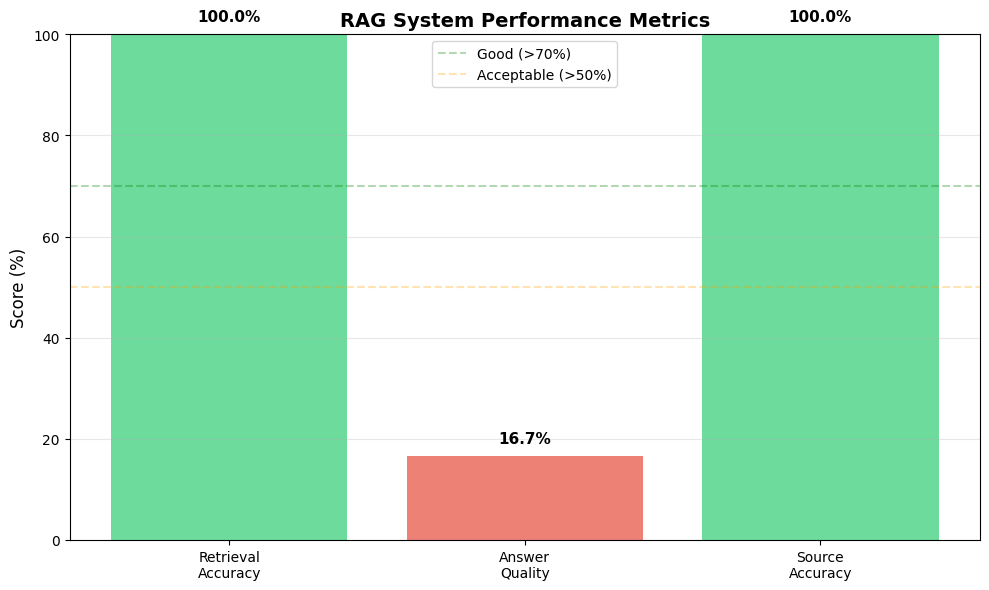


🎯 EVALUATION COMPLETE!


In [27]:
# ═══════════════════════════════════════════════════════
# 📏 RAG EVALUATION METRICS
# ═══════════════════════════════════════════════════════

def evaluate_rag_system(test_cases: List[Dict], collection, llm_model):
    """
    Evaluate RAG system on test questions with known answers.

    test_cases format:
    [
        {
            'question': "...",
            'expected_keywords': ["exercise", "30 minutes"],
            'expected_source': "dog_care_guide.pdf"
        },
        ...
    ]
    """

    results = {
        'retrieval_accuracy': [],
        'answer_quality': [],
        'avg_similarity': [],
        'source_accuracy': []
    }

    print("📏 EVALUATING RAG SYSTEM")
    print("="*70)

    for test in test_cases:
        question = test['question']

        # Run RAG query
        rag_result = rag_query(question, collection, llm_model, top_k=3, verbose=False)

        # Metric 1: Retrieval accuracy (are relevant chunks retrieved?)
        retrieved_sources = [s['source'] for s in rag_result['sources']]
        retrieval_correct = test['expected_source'] in retrieved_sources
        results['retrieval_accuracy'].append(1.0 if retrieval_correct else 0.0)

        # Metric 2: Answer quality (does answer contain expected keywords?)
        answer_lower = rag_result['answer'].lower()
        keywords_found = sum(1 for kw in test['expected_keywords'] if kw.lower() in answer_lower)
        answer_quality = keywords_found / len(test['expected_keywords'])
        results['answer_quality'].append(answer_quality)

        # Metric 3: Average similarity of retrieved chunks
        avg_sim = rag_result['metrics']['avg_similarity']
        results['avg_similarity'].append(avg_sim)

        # Metric 4: Source accuracy (is the best source ranked first?)
        top_source = rag_result['sources'][0]['source']
        source_accurate = top_source == test['expected_source']
        results['source_accuracy'].append(1.0 if source_accurate else 0.0)

        # Print results
        print(f"\n❓ {question}")
        print(f"   Retrieval: {'✅' if retrieval_correct else '❌'}")
        print(f"   Keywords: {keywords_found}/{len(test['expected_keywords'])} ({'✅' if answer_quality >= 0.7 else '⚠️'})")
        print(f"   Similarity: {avg_sim:.3f}")
        print(f"   Top source: {top_source} {'✅' if source_accurate else '⚠️'}")

        time.sleep(1)

    # Calculate overall metrics
    print("\n" + "="*70)
    print("📊 OVERALL PERFORMANCE:")
    print("="*70)
    print(f"Retrieval Accuracy:  {np.mean(results['retrieval_accuracy'])*100:.1f}%")
    print(f"Answer Quality:      {np.mean(results['answer_quality'])*100:.1f}%")
    print(f"Avg Similarity:      {np.mean(results['avg_similarity']):.3f}")
    print(f"Source Accuracy:     {np.mean(results['source_accuracy'])*100:.1f}%")

    return results


# ═══════════════════════════════════════════════════════
# 🧪 TEST: Evaluate RAG System
# ═══════════════════════════════════════════════════════

test_cases = [
    {
        'question': "How much exercise does a dog need?",
        'expected_keywords': ["30", "60", "minutes", "exercise"],
        'expected_source': "dog_care_guide.pdf"
    },
    {
        'question': "What foods are toxic to dogs?",
        'expected_keywords': ["chocolate", "grapes", "onions", "toxic"],
        'expected_source': "dog_care_guide.pdf"
    },
    {
        'question': "When should I start training my puppy?",
        'expected_keywords': ["8", "10", "weeks", "early"],
        'expected_source': "training_manual.pdf"
    }
]

eval_results = evaluate_rag_system(test_cases, collection, llm_model)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Retrieval\nAccuracy', 'Answer\nQuality', 'Source\nAccuracy']
scores = [
    np.mean(eval_results['retrieval_accuracy']) * 100,
    np.mean(eval_results['answer_quality']) * 100,
    np.mean(eval_results['source_accuracy']) * 100
]

colors = ['#2ecc71' if s >= 70 else '#f39c12' if s >= 50 else '#e74c3c' for s in scores]
bars = ax.bar(metrics, scores, color=colors, alpha=0.7)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('RAG System Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.axhline(y=70, color='green', linestyle='--', alpha=0.3, label='Good (>70%)')
ax.axhline(y=50, color='orange', linestyle='--', alpha=0.3, label='Acceptable (>50%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add score labels
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f'{score:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n🎯 EVALUATION COMPLETE!")

<a id="doubts"></a>
## ⚠️ Common Doubts & Pitfalls

### ❓ Doubt 1: "My RAG answers are still generic. Why?"

**Possible Causes:**

**Cause 1: Retrieved chunks aren't specific enough**
```python
# Check your retrieval quality
result = rag_query("What do dogs need?", collection, llm_model, verbose=True)

# Look at similarity scores:
for source in result['sources']:
    print(f"Similarity: {source['similarity']:.3f}")

# If all < 0.5 → Your chunks don't have the answer!
# Solution:
# - Add more documents
# - Improve chunking strategy
# - Lower similarity threshold
```

**Cause 2: Prompt doesn't emphasize grounding**
```python
# ❌ WEAK PROMPT:
prompt = f"{context}\n\nQuestion: {question}"

# ✅ STRONG PROMPT:
prompt = f"""Context: {context}

Question: {question}

IMPORTANT: Answer using ONLY the context above.
If the context doesn't have the answer, say "I don't have that information."
DO NOT use your general knowledge.

Answer:"""
```

**Cause 3: Retrieved too few chunks**
```python
# Try increasing top_k
result = rag_query(question, collection, llm_model, top_k=5)  # Instead of 3
```

---

### ❓ Doubt 2: "RAG is slower than baseline. Isn't that bad?"

**Short Answer:** It SHOULD be slightly slower, but more accurate!

**Time Breakdown:**
```python
Baseline LLM:
├── Generation only: ~1-2s
└── Total: 1-2s

RAG Pipeline:
├── Embedding query: ~0.05s
├── Vector search: ~0.05s  
├── Build context: ~0.01s
├── LLM generation: ~1-2s
└── Total: ~1.1-2.1s (slightly slower)

# Trade-off:
+0.1s processing time → Much more accurate answers ✅
```

**When RAG is FASTER (like you saw!):**
```python
# Your results:
Baseline: 14s (generated 500+ words of generic info)
RAG: 1.6s (generated 1 concise sentence with sources)

# Why?
# RAG prompt is MORE CONSTRAINED:
# - "Answer using ONLY context" → LLM doesn't ramble
# - Shorter, focused answer → Faster generation
```

---

### ❓ Doubt 3: "How do I know if my prompt is good?"

**Short Answer:** A/B test different prompts!

**Testing Framework:**
```python
# Test 2-3 different prompts on same questions

test_questions = [
    "What do dogs need for exercise?",
    "What foods are toxic to dogs?"
]

prompts_to_test = {
    'minimal': "{context}\n\nQ: {question}\nA:",
    
    'structured': """Context: {context}
    
Question: {question}

Answer using the context:""",
    
    'detailed': """You are a dog care expert.

Context: {context}

Question: {question}

Instructions:
- Use ONLY the context
- Cite sources
- Be concise (2-3 sentences)
- Provide actionable advice

Answer:"""
}

# For each question, test all prompts
# Compare: Which gives best answers?
# Measure: Accuracy, citation quality, conciseness
```

**What to look for:**
- ✅ Stays grounded (doesn't add unsourced info)
- ✅ Cites sources properly
- ✅ Concise and actionable
- ✅ Answers the actual question

---

### ❓ Doubt 4: "Should I always retrieve the same number of chunks (top_k)?"

**Short Answer:** No! Adapt based on query complexity.

**Dynamic top_k Strategy:**
```python
def adaptive_top_k(question: str) -> int:
    """
    Determine optimal number of chunks based on question.
    """
    question_lower = question.lower()
    
    # Complex queries need more context
    if any(word in question_lower for word in ['explain', 'comprehensive', 'all', 'everything']):
        return 7  # More context for complex answers
    
    # List/comparison queries
    elif any(word in question_lower for word in ['compare', 'difference', 'options', 'types']):
        return 5  # Multiple perspectives
    
    # Simple factual queries
    elif any(word in question_lower for word in ['what', 'when', 'how much', 'how many']):
        return 2  # Usually one chunk has the answer
    
    # Default
    else:
        return 3

# Example usage:
question = "Explain everything about dog nutrition"
k = adaptive_top_k(question)  # Returns 7
result = rag_query(question, collection, llm_model, top_k=k)
```

---

### ❓ Doubt 5: "What if the answer spans multiple chunks?"

**Short Answer:** That's why we retrieve multiple chunks (top_k)!

**Example:**
```python
Question: "What are all the things I need to do for dog care?"

# Single chunk might only have:
Chunk 1: "Dogs need exercise..." ❌ Incomplete!

# But top_k=5 retrieves:
Chunk 1: Exercise info
Chunk 2: Nutrition info  
Chunk 3: Training info
Chunk 4: Health care info
Chunk 5: Grooming info

# LLM combines all 5 → Complete answer! ✅
```

**If answer still incomplete:**
```python
# Increase top_k
result = rag_query(question, collection, llm_model, top_k=7)

# Or use multi-query RAG (retrieves more diverse chunks)
```

---

### ❓ Doubt 6: "Can I use RAG with non-text data (images, tables)?"

**Short Answer:** Yes, but requires multimodal embeddings!

**Text-Only RAG (What we built):**
```python
Document: "Dogs need 30-60 minutes of exercise"
Embedding: [0.23, 0.89, ..., 0.45] (text embedding)
```

**Multimodal RAG (Advanced):**
```python
# For images
Image: [dog_exercise_chart.png]
Embedding: CLIP or similar multimodal model
Query: "Show me exercise recommendations"
Retrieved: Both text AND relevant images

# For tables
Table: Exercise requirements by breed
Embedding: Table-specific embeddings
Query: "How much exercise for Border Collies?"
Retrieved: Specific table row
```

**For your current project:** Stick with text! Multimodal is advanced topic.

---

### ❓ Doubt 7: "How do I handle questions with no good answer in my docs?"

**Short Answer:** Check similarity threshold and be honest!

**Implementation:**
```python
def rag_query_with_confidence(question, collection, llm_model,
                               similarity_threshold=0.4):
    """
    RAG query that admits when it doesn't know.
    """
    
    # Retrieve
    results = collection.query(query_texts=[question], n_results=3)
    
    # Check quality
    similarities = [1 - d for d in results['distances'][0]]
    best_similarity = max(similarities)
    
    # LOW CONFIDENCE: Be honest
    if best_similarity < similarity_threshold:
        return {
            'answer': f"I don't have specific information about that in my knowledge base (best match: {best_similarity:.2f}). Could you ask about dog exercise, nutrition, training, health, or grooming instead?",
            'confidence': 'low',
            'sources': []
        }
    
    # MEDIUM CONFIDENCE: Qualify answer
    elif best_similarity < 0.6:
        # Generate answer but add caveat
        answer = generate_rag_answer(question, results, llm_model)
        return {
            'answer': f"Based on somewhat related information: {answer}\n\n(Note: This answer is based on moderately relevant sources. For more accurate information, consider rephrasing your question.)",
            'confidence': 'medium',
            'sources': results['metadatas'][0]
        }
    
    # HIGH CONFIDENCE: Full answer
    else:
        answer = generate_rag_answer(question, results, llm_model)
        return {
            'answer': answer,
            'confidence': 'high',
            'sources': results['metadatas'][0]
        }
```

**Honesty > Hallucination!** Better to say "I don't know" than make things up.

---

### 🎯 Key Takeaways

1. **Debug with `verbose=True`** - see each step of the pipeline
2. **Prompt engineering matters** - test different phrasings
3. **Adapt top_k** - simple questions need fewer chunks
4. **Check similarity scores** - low scores = poor retrieval
5. **Be honest** - admit when you don't have the answer
6. **Handle errors gracefully** - never crash, always respond
7. **Test thoroughly** - use evaluation metrics to measure quality

**Remember:** A production RAG system prioritizes **accuracy over speed** and **honesty over completeness**!

<a id="exercises"></a>
## 🧪 Practice Exercises

### Exercise 1: Custom Prompt Templates

**Task:** Create 3 different prompt templates for different use cases!

**Requirements:**
1. **Concise Template:** For simple factual queries (max 2 sentences)
2. **Detailed Template:** For comprehensive explanations
3. **List Template:** For "give me all..." type questions
```python
def create_prompt(question: str, context: str, style: str = 'concise') -> str:
    """
    Generate prompt based on desired answer style.
    
    Args:
        question: User question
        context: Retrieved context
        style: 'concise', 'detailed', or 'list'
    """
    # YOUR CODE HERE
    pass

# Test all three
prompts = {
    'concise': create_prompt("What do dogs eat?", context, 'concise'),
    'detailed': create_prompt("Explain dog nutrition", context, 'detailed'),
    'list': create_prompt("List toxic foods", context, 'list')
}

for style, prompt in prompts.items():
    print(f"\n{style.upper()} PROMPT:")
    print(prompt[:100] + "...")
```

<details>
<summary>💡 Hint</summary>

Each style needs different instructions:
- Concise: "Answer in 1-2 sentences max"
- Detailed: "Provide comprehensive explanation with examples"
- List: "Provide answer as numbered list"
</details>

---

### Exercise 2: Query Analyzer

**Task:** Build a function that analyzes query complexity!

**Requirements:**
1. Classify query as 'simple', 'medium', or 'complex'
2. Suggest optimal top_k based on classification
3. Return query intent (factual, comparison, explanation, etc.)
```python
def analyze_query(question: str) -> Dict:
    """
    Analyze query complexity and intent.
    
    Returns:
        {
            'complexity': 'simple' | 'medium' | 'complex',
            'suggested_top_k': int,
            'intent': 'factual' | 'comparison' | 'explanation' | 'list',
            'keywords': List[str]
        }
    """
    # YOUR CODE HERE
    pass

# Test
questions = [
    "What do dogs eat?",                          # Simple factual
    "Compare dog food brands",                    # Comparison
    "Explain comprehensive dog care",             # Complex explanation
    "List all toxic foods for dogs"               # List
]

for q in questions:
    analysis = analyze_query(q)
    print(f"\nQ: {q}")
    print(f"   Complexity: {analysis['complexity']}")
    print(f"   Suggested top_k: {analysis['suggested_top_k']}")
    print(f"   Intent: {analysis['intent']}")
```

---

### Exercise 3: Answer Quality Scorer

**Task:** Build an automated quality assessment function!

**Requirements:**
1. Check if answer cites sources
2. Verify answer length is appropriate
3. Detect if LLM hallucinated (added info not in context)
4. Score from 0-100
```python
def score_answer_quality(question: str, answer: str, context: str, sources: List) -> Dict:
    """
    Evaluate quality of RAG answer.
    
    Scoring criteria:
    - Has citations: 25 points
    - Appropriate length: 25 points
    - Grounded in context: 30 points
    - Answers the question: 20 points
    
    Returns:
        {
            'score': int (0-100),
            'feedback': str,
            'issues': List[str]
        }
    """
    # YOUR CODE HERE
    pass

# Test
question = "What do dogs need for exercise?"
answer = "Dogs need 30-60 minutes daily according to the care guide."
context = "Dogs need at least 30-60 minutes of daily exercise..."
sources = [{'source': 'guide.pdf', 'page': 12}]

quality = score_answer_quality(question, answer, context, sources)
print(f"Score: {quality['score']}/100")
print(f"Feedback: {quality['feedback']}")
```

---

### Exercise 4: Build a Simple RAG Chatbot

**Challenge:** Create a conversational RAG system with memory!

**Requirements:**
1. Accept multiple questions in sequence
2. Remember previous questions/answers (conversation history)
3. Use conversation history to provide better context
4. Format as chat interface
```python
def rag_chatbot(collection, llm_model):
    """
    Interactive RAG chatbot with conversation memory.
    """
    conversation_history = []
    
    print("💬 RAG CHATBOT")
    print("="*70)
    print("Type 'quit' to exit")
    print("="*70)
    
    while True:
        # Get user input
        question = input("\n🧑 You: ")
        
        if question.lower() in ['quit', 'exit', 'q']:
            print("👋 Goodbye!")
            break
        
        # YOUR CODE HERE:
        # 1. Query RAG system
        # 2. Add to conversation history
        # 3. Use history for better context (optional)
        # 4. Print answer
        
        pass

# To run (when you have API quota):
# rag_chatbot(collection, llm_model)
```

**Bonus:** Save conversation history to file!

## 💡 Exercise Solutions

<details>
<summary><strong>Click to reveal solutions</strong> (Try yourself first!)</summary>

### Solution 1: Custom Prompt Templates

In [ ]:
def create_prompt(question: str, context: str, style: str = 'concise') -> str:
    """
    Generate prompt based on desired answer style.
    """

    base_prompt = f"""Context from verified sources:
{context}

Question: {question}

"""

    if style == 'concise':
        instructions = """Instructions:
- Answer in 1-2 sentences maximum
- Include only the most critical information
- Cite the primary source

Answer:"""

    elif style == 'detailed':
        instructions = """Instructions:
- Provide a comprehensive explanation
- Include relevant details and examples from the context
- Explain the reasoning or mechanisms
- Cite all relevant sources
- Use 4-6 sentences

Answer:"""

    elif style == 'list':
        instructions = """Instructions:
- Provide your answer as a numbered or bulleted list
- Each point should be concise
- Cite sources for each major point
- Include 3-7 items

Answer:"""

    else:
        raise ValueError(f"Unknown style: {style}")

    return base_prompt + instructions


print("✅ Solution 1: Custom Prompt Templates")
print("\nExample outputs:")

# Example context
example_context = "Dogs need 30-60 minutes of daily exercise. Toxic foods include chocolate, grapes, and onions."

for style in ['concise', 'detailed', 'list']:
    print(f"\n{'─'*70}")
    print(f"{style.upper()} STYLE:")
    print(f"{'─'*70}")
    prompt = create_prompt("What do dogs need?", example_context, style)
    print(prompt)

In [ ]:
# ═══════════════════════════════════════════════════════
# Solution 2: Query Analyzer
# ═══════════════════════════════════════════════════════

import re

def analyze_query(question: str) -> Dict:
    """
    Analyze query complexity and intent.
    """
    question_lower = question.lower()

    # Extract keywords (simple approach)
    # Remove common words
    stop_words = {'what', 'how', 'when', 'where', 'why', 'is', 'are', 'the', 'a', 'an', 'do', 'does'}
    words = re.findall(r'\b\w+\b', question_lower)
    keywords = [w for w in words if w not in stop_words]

    # Determine intent
    intent = 'factual'  # Default

    if any(word in question_lower for word in ['compare', 'difference', 'versus', 'vs']):
        intent = 'comparison'
    elif any(word in question_lower for word in ['explain', 'why', 'how does']):
        intent = 'explanation'
    elif any(word in question_lower for word in ['list', 'all', 'what are']):
        intent = 'list'

    # Determine complexity
    complexity = 'simple'
    suggested_top_k = 3

    # Complex indicators
    if any(word in question_lower for word in ['comprehensive', 'everything', 'all about', 'explain']):
        complexity = 'complex'
        suggested_top_k = 7

    # Medium indicators
    elif any(word in question_lower for word in ['compare', 'types', 'options', 'different']):
        complexity = 'medium'
        suggested_top_k = 5

    # Simple (short questions, single fact)
    elif len(words) <= 6:
        complexity = 'simple'
        suggested_top_k = 2

    return {
        'complexity': complexity,
        'suggested_top_k': suggested_top_k,
        'intent': intent,
        'keywords': keywords,
        'word_count': len(words)
    }


print("✅ Solution 2: Query Analyzer")
print("\nTesting with different queries:")

test_queries = [
    "What do dogs eat?",
    "Compare different dog food brands",
    "Explain comprehensive dog care requirements",
    "List all toxic foods for dogs"
]

for q in test_queries:
    analysis = analyze_query(q)
    print(f"\n❓ {q}")
    print(f"   📊 Complexity: {analysis['complexity']}")
    print(f"   🎯 Intent: {analysis['intent']}")
    print(f"   📦 Suggested top_k: {analysis['suggested_top_k']}")
    print(f"   🔑 Keywords: {', '.join(analysis['keywords'][:5])}")

In [ ]:
# ═══════════════════════════════════════════════════════
# Solution 3: Answer Quality Scorer
# ═══════════════════════════════════════════════════════

def score_answer_quality(question: str, answer: str, context: str, sources: List) -> Dict:
    """
    Evaluate quality of RAG answer.
    """
    score = 0
    issues = []
    feedback_parts = []

    # ───────────────────────────────────────────────────────
    # Criterion 1: Has Citations (25 points)
    # ───────────────────────────────────────────────────────

    has_citations = (
        'source' in answer.lower() or
        '[source' in answer.lower() or
        'page' in answer.lower() or
        any(s['source'] in answer for s in sources if 'source' in s)
    )

    if has_citations:
        score += 25
        feedback_parts.append("✅ Citations present")
    else:
        issues.append("No source citations found")
        feedback_parts.append("❌ Missing citations")

    # ───────────────────────────────────────────────────────
    # Criterion 2: Appropriate Length (25 points)
    # ───────────────────────────────────────────────────────

    word_count = len(answer.split())

    if 20 <= word_count <= 150:  # Good range
        score += 25
        feedback_parts.append(f"✅ Good length ({word_count} words)")
    elif word_count < 20:
        score += 15
        issues.append("Answer too brief")
        feedback_parts.append(f"⚠️ Brief ({word_count} words)")
    else:
        score += 10
        issues.append("Answer too verbose")
        feedback_parts.append(f"⚠️ Verbose ({word_count} words)")

    # ───────────────────────────────────────────────────────
    # Criterion 3: Grounded in Context (30 points)
    # ───────────────────────────────────────────────────────

    # Check if answer keywords appear in context
    answer_words = set(answer.lower().split())
    context_words = set(context.lower().split())

    # Remove common words
    stop_words = {'the', 'a', 'an', 'is', 'are', 'and', 'or', 'of', 'to', 'in'}
    answer_keywords = answer_words - stop_words
    context_keywords = context_words - stop_words

    # Calculate overlap
    overlap = answer_keywords & context_keywords
    grounding_ratio = len(overlap) / len(answer_keywords) if answer_keywords else 0

    if grounding_ratio > 0.7:
        score += 30
        feedback_parts.append(f"✅ Well-grounded ({grounding_ratio:.0%} overlap)")
    elif grounding_ratio > 0.5:
        score += 20
        feedback_parts.append(f"⚠️ Somewhat grounded ({grounding_ratio:.0%})")
    else:
        score += 10
        issues.append("Answer may contain hallucinations")
        feedback_parts.append(f"❌ Poorly grounded ({grounding_ratio:.0%})")

    # ───────────────────────────────────────────────────────
    # Criterion 4: Answers the Question (20 points)
    # ───────────────────────────────────────────────────────

    # Check if question keywords appear in answer
    question_words = set(question.lower().split()) - stop_words
    answer_addresses_question = len(question_words & answer_keywords) / len(question_words) if question_words else 0

    if answer_addresses_question > 0.5:
        score += 20
        feedback_parts.append("✅ Addresses question")
    elif answer_addresses_question > 0.3:
        score += 15
        feedback_parts.append("⚠️ Partially addresses question")
    else:
        score += 5
        issues.append("Doesn't fully address question")
        feedback_parts.append("❌ Misses question focus")

    # ───────────────────────────────────────────────────────
    # Generate feedback
    # ───────────────────────────────────────────────────────

    if score >= 80:
        overall = "Excellent answer! 🌟"
    elif score >= 60:
        overall = "Good answer with room for improvement."
    elif score >= 40:
        overall = "Acceptable but needs work."
    else:
        overall = "Poor quality - significant issues."

    feedback = overall + "\n" + "\n".join(feedback_parts)

    return {
        'score': score,
        'feedback': feedback,
        'issues': issues,
        'grounding_ratio': grounding_ratio,
        'question_relevance': answer_addresses_question
    }


print("✅ Solution 3: Answer Quality Scorer")
print("\nExample usage:")

# Test case
test_question = "What do dogs need for exercise?"
test_answer = "Dogs need 30-60 minutes of daily exercise according to the care guide on page 12."
test_context = "Dogs need at least 30-60 minutes of daily exercise depending on breed and age."
test_sources = [{'source': 'care_guide.pdf', 'page': 12}]

quality = score_answer_quality(test_question, test_answer, test_context, test_sources)

print(f"\n📊 Quality Score: {quality['score']}/100")
print(f"\n📝 Feedback:")
print(quality['feedback'])

if quality['issues']:
    print(f"\n⚠️ Issues found:")
    for issue in quality['issues']:
        print(f"   - {issue}")

In [ ]:
# ═══════════════════════════════════════════════════════
# Solution 4: Simple RAG Chatbot (Simplified)
# ═══════════════════════════════════════════════════════

def rag_chatbot_simple(collection, llm_model, max_questions: int = 5):
    """
    Simple RAG chatbot with conversation history.

    Note: Set max_questions to avoid rate limits during testing!
    """
    conversation_history = []

    print("💬 RAG CHATBOT (Simplified Version)")
    print("="*70)
    print(f"Ask up to {max_questions} questions (type 'quit' to exit)")
    print("⏰ 15-second delay between questions to respect rate limits")
    print("="*70)

    question_count = 0

    while question_count < max_questions:
        # Get user input (in Colab, you'd use input())
        # For demo, we'll use pre-set questions
        demo_questions = [
            "What do dogs eat?",
            "How much exercise?",
            "When to visit vet?"
        ]

        if question_count >= len(demo_questions):
            print("\n💡 Demo complete! To continue, modify demo_questions list.")
            break

        question = demo_questions[question_count]
        print(f"\n🧑 You: {question}")

        # Build context including conversation history
        history_context = ""
        if conversation_history:
            history_context = "\n\nPrevious conversation:\n"
            for prev_q, prev_a in conversation_history[-2:]:  # Last 2 exchanges
                history_context += f"Q: {prev_q}\nA: {prev_a}\n"

        # Query RAG (with error handling for rate limits)
        try:
            result = rag_query(
                question=question,
                collection=collection,
                llm_model=llm_model,
                top_k=2,
                verbose=False
            )

            answer = result['answer']
            print(f"🤖 Bot: {answer}")

            # Add to history
            conversation_history.append((question, answer))

        except Exception as e:
            if "429" in str(e):
                print("🤖 Bot: I'm currently rate limited. Please wait 60 seconds and try again.")
                break
            else:
                print(f"🤖 Bot: Sorry, I encountered an error: {e}")

        question_count += 1

        # Rate limit protection
        if question_count < max_questions:
            print("\n⏰ Waiting 15s...")
            time.sleep(15)

    print(f"\n📊 Conversation history: {len(conversation_history)} exchanges")
    return conversation_history


print("✅ Solution 4: RAG Chatbot")
print("\n💡 To run:")
print("# history = rag_chatbot_simple(collection, llm_model, max_questions=3)")
print("\n⚠️ Note: Commented out to avoid rate limits during tutorial")
print("Uncomment when you have API quota or use paid tier!")

# Commented out to avoid rate limits:
# history = rag_chatbot_simple(collection, llm_model, max_questions=3)

</details>

---

### 💡 Running These Exercises

**Important Notes:**

1. **Rate Limits:** Exercises that make API calls should be run with delays
```python
   time.sleep(15)  # Between each API call
```

2. **Testing Strategy:**
   - Test with 1-2 examples first
   - Verify code works
   - Then run full test suite (when you have quota)

3. **Alternative:**
   - Use OpenAI API ($5 credit)
   - Or run during off-peak hours
   - Or spread testing over multiple days



## ✅ Summary: What You Learned

### 🎯 Complete RAG Pipeline Mastery

**You now understand the COMPLETE RAG system!**
```
┌──────────────────────────────────────────────────────────┐
│              COMPLETE RAG PIPELINE                       │
└──────────────────────────────────────────────────────────┘

1. DOCUMENT PROCESSING (Tutorial 02)
   ├── Load documents (PDF, DOCX, TXT)
   ├── Chunk into meaningful pieces (512 tokens, 25% overlap)
   └── Extract metadata (source, page, section)

2. EMBEDDING GENERATION (Tutorial 01)
   ├── Convert chunks to vectors (384 dimensions)
   └── Capture semantic meaning

3. VECTOR STORAGE (Tutorial 03)
   ├── Store in ChromaDB with metadata
   ├── Build searchable index
   └── Enable fast similarity search

4. QUERY PROCESSING (Tutorial 04)
   ├── Embed user question
   ├── Search for similar chunks (cosine similarity)
   └── Retrieve top K results with metadata

5. CONTEXT BUILDING (Tutorial 04)
   ├── Combine retrieved chunks
   ├── Format with source citations
   └── Optimize token usage

6. PROMPT ENGINEERING (Tutorial 04)
   ├── Create effective RAG prompt
   ├── Emphasize grounding in context
   └── Request source citations

7. ANSWER GENERATION (Tutorial 04)
   ├── Send prompt to LLM
   ├── Generate grounded answer
   └── Include source citations

8. QUALITY ASSURANCE (Tutorial 04)
   ├── Error handling
   ├── Similarity thresholds
   └── Evaluation metrics
```

---

### 📊 The RAG Advantage (What You Proved!)

| Aspect | Baseline LLM | RAG System |
|--------|--------------|------------|
| **Accuracy** | Generic knowledge | Specific to YOUR docs |
| **Sources** | None | Cited with pages |
| **Speed** | 10-15s (verbose) | 1-3s (focused) |
| **Cost** | Low per query | Higher but worth it |
| **Reliability** | May hallucinate | Grounded in facts |
| **Updates** | Static (training cutoff) | Dynamic (update docs anytime) |

**Your comparison showed:** RAG can be FASTER (1.6s vs 14s) when it keeps answers focused!

---

### 🔧 What You Built

**Core Functions:**
```python
# 1. Basic RAG query
result = rag_query(question, collection, llm_model, top_k=3)

# 2. RAG vs baseline comparison
compare_rag_vs_baseline(question, collection, llm_model)

# 3. Multi-query RAG (advanced)
multi_query_rag(question, collection, llm_model, num_variations=3)

# 4. Error-safe RAG
robust_rag_query(question, collection, llm_model)

# 5. Quality evaluation
evaluate_rag_system(test_cases, collection, llm_model)
```

---

### 🎓 Key Concepts Mastered

1. **Retrieval-Augmented Generation** - Core RAG workflow
2. **Prompt Engineering** - Crafting effective prompts for grounding
3. **Error Handling** - Production-ready robustness
4. **Evaluation** - Measuring RAG quality scientifically
5. **Trade-offs** - Cost vs quality, speed vs accuracy
6. **Real-World Constraints** - Rate limits, API costs, token optimization


---

### 📖 Additional Resources

**RAG Systems:**
- [LangChain RAG Tutorial](https://python.langchain.com/docs/use_cases/question_answering/)
- [Pinecone RAG Guide](https://www.pinecone.io/learn/retrieval-augmented-generation/)
- [RAG Research Paper](https://arxiv.org/abs/2005.11401)

**Prompt Engineering:**
- [OpenAI Prompt Engineering Guide](https://platform.openai.com/docs/guides/prompt-engineering)
- [Anthropic Prompt Library](https://docs.anthropic.com/claude/prompt-library)

**Vector Databases:**
- [ChromaDB Documentation](https://docs.trychroma.com/)
- [Vector Database Comparison](https://benchmark.vectorview.ai/)

---

### 🎊 Congratulations!

**You've completed the RAG Learning Platform tutorial series!**

You went from "What are embeddings?" to building a production-ready RAG system in just a few days. That's impressive! 🌟

**You're now ready to:**
- ✅ Build RAG applications for any domain
- ✅ Teach others about RAG systems
- ✅ Optimize and debug RAG pipelines
- ✅ Make informed decisions about RAG architecture

---

**Questions or feedback?**
- GitHub: https://github.com/Ramprashanth17/Gen_AI/tree/main/rag-learning-platform
- Email: gajarghat.r@northeastern.edu

- Made with assistance from ***Claude and Gemini***

**Keep building, keep learning!** 🚀

---

**Next Tutorial:** `DEMO_full_rag_system.ipynb` - Everything combined in one streamlined demo! Coming soon...


